In [4]:
import pandas as pd

games_df = pd.read_csv(
    "Steam Games Dataset/games.csv",
    low_memory=False
)

vgsales_df = pd.read_csv(
    "Video Game Sales/vgsales.csv",
    low_memory=False
)

steam_store_df = pd.read_csv(
    "Steam Store Games (Clean dataset)/steam.csv",
    low_memory=False
)

games_df.columns = (
    games_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

vgsales_df.columns = (
    vgsales_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

steam_store_df.columns = (
    steam_store_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Games:", games_df.shape)
print("Video Sales:", vgsales_df.shape)
print("Steam Store:", steam_store_df.shape)

Games: (122611, 39)
Video Sales: (16598, 11)
Steam Store: (27075, 18)


,positive_rating_percent,peak_ccu
positive_rating_percent,1.000000,-0.001775
peak_ccu,-0.001775,1.000000


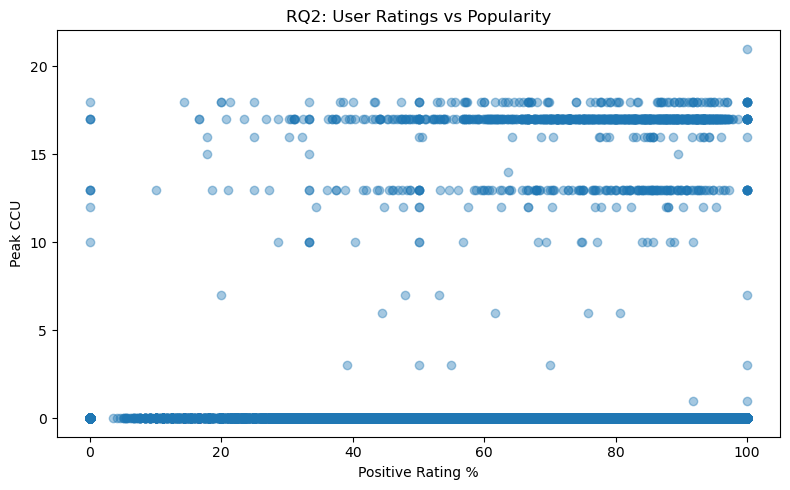

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import os
os.makedirs("Figures", exist_ok=True)
os.makedirs("Tables", exist_ok=True)

rq2 = games_df[['positive', 'negative', 'peak_ccu']].copy()

for col in rq2.columns:
    rq2[col] = pd.to_numeric(rq2[col], errors='coerce')

rq2 = rq2.dropna()
rq2['total_reviews'] = rq2['positive'] + rq2['negative']
rq2['positive_rating_percent'] = (rq2['positive'] / rq2['total_reviews']) * 100

rq2_table = rq2[['positive_rating_percent', 'peak_ccu']].corr()
rq2_table.to_csv("Tables/RQ2_ratings_popularity.csv")

display(rq2_table)

plt.figure(figsize=(8,5))
plt.scatter(rq2['positive_rating_percent'], rq2['peak_ccu'], alpha=0.4)
plt.title("RQ2: User Ratings vs Popularity")
plt.xlabel("Positive Rating %")
plt.ylabel("Peak CCU")
plt.tight_layout()
plt.savefig("Figures/RQ2_ratings_popularity.png")
plt.show()